<center>
<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%);
            padding: 12px 40px;
            border-radius: 8px;
            border-left: 4px solid #00d4ff;
            box-shadow: 0 4px 20px rgba(0, 212, 255, 0.15);
            margin: 15px 0;
            width: 100%;
            box-sizing: border-box;">
    <h1 style="color: #00d4ff; 
               font-family: 'Consolas', 'Courier New', monospace; 
               font-size: 28px; 
               font-weight: 700; 
               margin: 0;
               letter-spacing: 1px;
               text-shadow: 0 0 20px rgba(0, 212, 255, 0.3);
               text-align: center;">
        🎯 DATA_GENERATION
    </h1>
    <p style="color: rgba(255,255,255,0.6); 
              font-size: 13px; 
              margin: 4px 0 0 0;
              font-family: 'Consolas', 'Courier New', monospace;
              letter-spacing: 0.5px;
              text-align: center;">
        synthetic_data · visualization · geometry
    </p>
</div>
</center>

## 📐 1. Многомерное нормальное распределение

### Что это и зачем нам?

Для генерации синтетических данных для SVM нам нужно создавать **облака точек** — классы, которые мы будем разделять. Самое естественное и контролируемое распределение для этого — **многомерное нормальное (гауссовское)** распределение.

Обычное (одномерное) нормальное распределение задаётся двумя числами: средним $\mu$ и дисперсией $\sigma^2$.

В двумерном случае (наш график, две оси) распределение задаётся:

- **вектором среднего** $\mu = (\mu_x, \mu_y)$ — это координаты центра облака точек
- **ковариационной матрицей** $\Sigma$ — это то, что определяет **форму** облака (круг, овал, наклон)

$$\Sigma = \begin{pmatrix}\sigma_x^2 & \sigma_{xy}\\ \sigma_{xy} & \sigma_y^2\end{pmatrix}$$

**Метод numpy.random.multivariate_normal**:
https://numpy.org/doc/2.1/reference/random/generated/numpy.random.multivariate_normal.html

### Как эта матрица управляет формой облака

- **$\sigma_x^2$** — разброс вдоль оси X (дисперсия по x). Чем больше — тем шире облако **по горизонтали**.
- **$\sigma_y^2$** — разброс вдоль оси Y. Чем больше — тем выше облако **по вертикали**.
- **$\sigma_{xy}$** (недиагональный элемент, ковариация) — это то, что **наклоняет** овал. Если он равен нулю, оси овала параллельны осям координат (никакого наклона). Если он ненулевой — облако превращается в **наклонённый эллипс** (точки с большим x чаще имеют и большой y, если ковариация положительная).

### Практическое правило для формы

| Что хочешь получить | Как задать $\Sigma$ |
|---|---|
| Круг | $\sigma_x^2 = \sigma_y^2$, $\sigma_{xy} = 0$ |
| Овал вытянут по горизонтали | $\sigma_x^2 > \sigma_y^2$, $\sigma_{xy} = 0$ |
| Овал вытянут по вертикали | $\sigma_y^2 > \sigma_x^2$, $\sigma_{xy} = 0$ |
| Наклонённый овал | $\sigma_{xy} \neq 0$ (чем ближе к $\sqrt{\sigma_x^2 \sigma_y^2}$, тем сильнее "сплющен" по диагонали) |

### Как это генерируется — на уровне идеи (без кода)

Функция для генерации из многомерного нормального распределения принимает три вещи: вектор среднего (куда "поставить" центр облака — фактически задаёт положение целого класса на плоскости), ковариационную матрицу (форму и наклон), и количество точек. На выходе — массив формы `(n, 2)` — то есть `n` строк (объектов), 2 столбца (координаты x, y). Это уже готовый numpy-массив в правильном формате для одного класса.

### Как сделать два класса

Генерируешь **два независимых облака** с разными координатами (чтобы они не совпадали в пространстве — иначе не будет никакой разделимости вообще) и, возможно, разной формой ковариации (можно сделать один класс кругом, другой — овалом, для разнообразия). Потом эти два массива **склеиваешь по строкам** (`np.vstack` или `np.concatenate` по оси 0) — получаешь единый массив `X`, и отдельно создаёшь вектор меток `y` той же длины (например, первые `n1` меток = `-1`, следующие `n2` = `+1`).

In [51]:
# Создание массивов и их объединение

import numpy as np

# координаты среднего
coordinate_vector_1 = np.array([-2, 0])

# ковариационная матрица
sigma_1 = np.array([[0.5, 0.0],
                    [0.0, 0.5]])

# Создание облака точек
X_1 = np.random.multivariate_normal(coordinate_vector_1, sigma_1, 5)
y_1 = -np.ones(5)


# второй массив
coordinate_vector_2 = np.array([2, 0])

sigma_2 = np.array([[0.5, 0.0],
                    [0.0, 0.5]])

X_2 = np.random.multivariate_normal(coordinate_vector_2, sigma_2, 5)
y_2 = np.ones(5)

# Теперь у нас имеется X_1 и X_2, они имеют по пять координат по Ox и Oy
# Теперь их надо объединить, порядок важен

# Склеиваются они по порядку
X = np.concatenate([X_1, X_2], axis=0) # по вертикали
y = np.concatenate([y_1, y_2], axis=0) # по горизонтали - то есть склеиваем два ряда в один

# вот они
for i in range(len(X)):
    print(f"Точка {i}: X = ({X[i, 0]:.2f}, {X[i, 1]:.2f}), класс = {int(y[i])}")

Точка 0: X = (-2.21, -1.84), класс = -1
Точка 1: X = (-2.26, -0.05), класс = -1
Точка 2: X = (-2.71, -0.36), класс = -1
Точка 3: X = (-0.92, 0.47), класс = -1
Точка 4: X = (-2.65, -1.13), класс = -1
Точка 5: X = (1.77, -0.15), класс = 1
Точка 6: X = (2.35, -0.38), класс = 1
Точка 7: X = (2.36, 1.37), класс = 1
Точка 8: X = (2.58, -0.03), класс = 1
Точка 9: X = (1.87, -0.25), класс = 1


<pre>
X — склеиваем по вертикали (vstack / axis=0)

X_1:            X_2:            Результат:
[1.0, 2.0]      [7.0, 8.0]      [1.0, 2.0]
[3.0, 4.0]      [9.0, 10.0]     [3.0, 4.0]
[5.0, 6.0]       ...            [5.0, 6.0]
                                 [7.0, 8.0]
                                 [9.0, 10.0]
                                 ...
Увеличивается число строк: (5,2) + (5,2) → (10,2)

y — склеиваем по горизонтали (hstack)

y_1:      y_2:      Результат:
[0]       [1]       [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
[0]       [1]
[0]       [1]
[0]       [1]
[0]       [1]
Увеличивается длина вектора: (5,) + (5,) → (10,)
</pre>

X shape: (400, 2)
y shape: (400,)


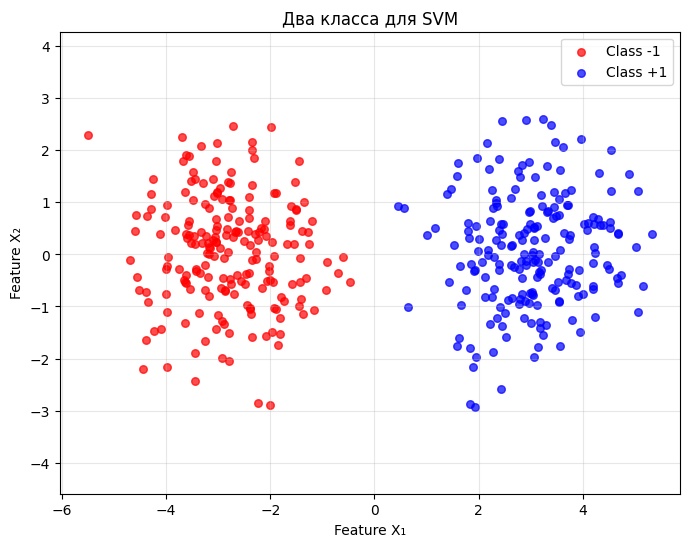

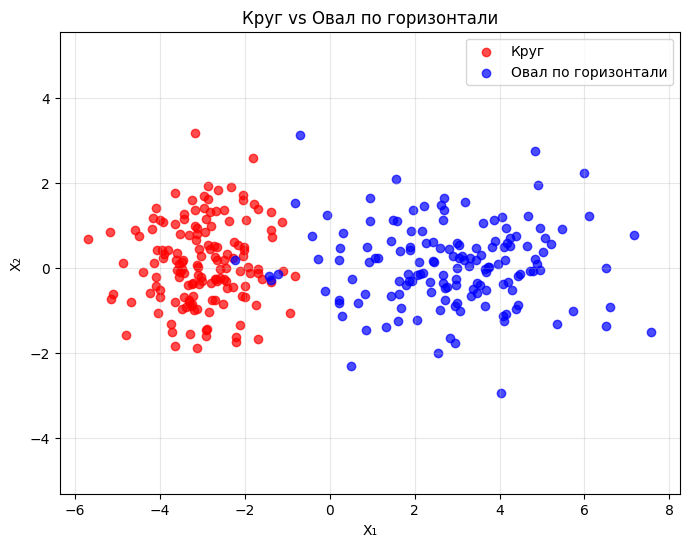

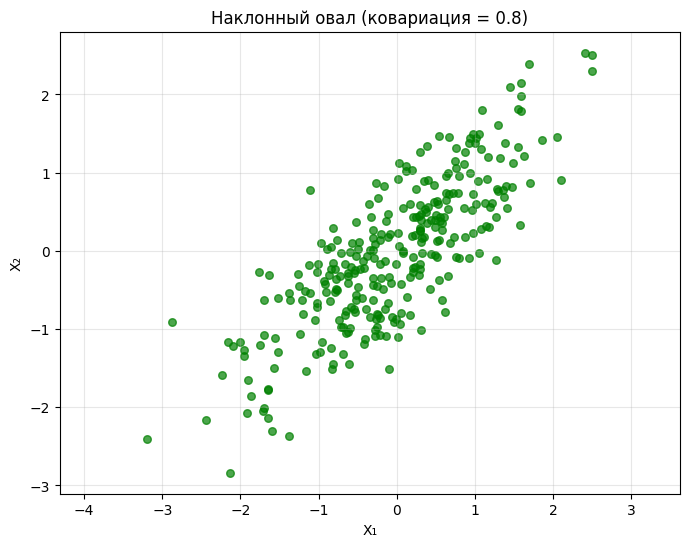


ОБЪЯСНЕНИЕ ПАРАМЕТРОВ:
mu = [среднее_по_X, среднее_по_Y]
  → задаёт положение центра облака на плоскости

sigma = [[σx², σxy],
         [σxy, σy²]]
  → σx² = дисперсия по X (ширина облака)
  → σy² = дисперсия по Y (высота облака)
  → σxy = ковариация (наклон облака)

Формы облака:
  • Круг:           σx² = σy², σxy = 0
  • Овал по X:      σx² > σy², σxy = 0
  • Овал по Y:      σy² > σx², σxy = 0
  • Наклонный:      σxy ≠ 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


n_samples = 200  # количество точек

# Вектор среднего (центр облака)
mu = np.array([0, 0])  # [среднее по X, среднее по Y]

# Ковариационная матрица (форма облака)
# [[дисперсия по X, ковариация X-Y],
#  [ковариация X-Y, дисперсия по Y]]
sigma = np.array([[1.0, 0.0],   # круг: дисперсии равны, ковариация = 0
                  [0.0, 1.0]])

# Генерируем точки из многомерного нормального распределения
# np.random.multivariate_normal(среднее, ковариация, количество_точек)
X_class = np.random.multivariate_normal(mu, sigma, n_samples)

# ============================================
# 2. Объяснение параметров (закомментировано)
# ============================================

# Чтобы получить КРУГ:
# sigma = np.array([[1.0, 0.0],
#                   [0.0, 1.0]])
# # дисперсии равны (1.0 и 1.0), ковариация = 0

# Чтобы получить ОВАЛ ПО ГОРИЗОНТАЛИ (широкий):
# sigma = np.array([[3.0, 0.0],   # дисперсия по X больше
#                   [0.0, 1.0]])  # дисперсия по Y меньше

# Чтобы получить ОВАЛ ПО ВЕРТИКАЛИ (высокий):
# sigma = np.array([[1.0, 0.0],   # дисперсия по X меньше
#                   [0.0, 3.0]])  # дисперсия по Y больше

# Чтобы получить НАКЛОННЫЙ ОВАЛ:
# sigma = np.array([[1.0, 0.8],   # ковариация ≠ 0
#                   [0.8, 1.0]])  # облако наклонено по диагонали

# ============================================
# 3. Генерация двух классов (для SVM)
# ============================================

# Класс -1: центр в (-3, 0), круглая форма
mu_1 = np.array([-3, 0])
sigma_1 = np.array([[1.0, 0.0],
                    [0.0, 1.0]])
X_1 = np.random.multivariate_normal(mu_1, sigma_1, n_samples)
y_1 = -np.ones(n_samples)  # метки класса -1

# Класс +1: центр в (3, 0), круглая форма
mu_2 = np.array([3, 0])
sigma_2 = np.array([[1.0, 0.0],
                    [0.0, 1.0]])
X_2 = np.random.multivariate_normal(mu_2, sigma_2, n_samples)
y_2 = np.ones(n_samples)   # метки класса +1

# Склеиваем данные в один массив
X = np.vstack([X_1, X_2])      # объединяем по строкам
y = np.hstack([y_1, y_2])      # объединяем метки

print(f"X shape: {X.shape}")   # (400, 2) — 400 точек, 2 признака
print(f"y shape: {y.shape}")   # (400,) — 400 меток

# ============================================
# 4. Визуализация
# ============================================

plt.figure(figsize=(8, 6))

# Точки класса -1 (красные)
plt.scatter(X[y == -1, 0], X[y == -1, 1],
            color='red', label='Class -1', s=30, alpha=0.7)

# Точки класса +1 (синие)
plt.scatter(X[y == 1, 0], X[y == 1, 1],
            color='blue', label='Class +1', s=30, alpha=0.7)

plt.xlabel('Feature X₁')
plt.ylabel('Feature X₂')
plt.title('Два класса для SVM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# ============================================
# 5. Другие формы облаков (примеры)
# ============================================

# Пример 1: Класс -1 круг, класс +1 овал по горизонтали
mu_1 = np.array([-3, 0])
sigma_1 = np.array([[1.0, 0.0], [0.0, 1.0]])  # круг

mu_2 = np.array([3, 0])
sigma_2 = np.array([[3.0, 0.0], [0.0, 1.0]])  # овал по горизонтали

X1 = np.random.multivariate_normal(mu_1, sigma_1, 150)
X2 = np.random.multivariate_normal(mu_2, sigma_2, 150)

plt.figure(figsize=(8, 6))
plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Круг', alpha=0.7)
plt.scatter(X2[:, 0], X2[:, 1], color='blue', label='Овал по горизонтали', alpha=0.7)
plt.xlabel('X₁')
plt.ylabel('X₂')
plt.title('Круг vs Овал по горизонтали')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# Пример 2: Наклонный овал
mu = np.array([0, 0])
sigma = np.array([[1.0, 0.8],   # ковариация = 0.8 (сильный наклон)
                  [0.8, 1.0]])

X_slanted = np.random.multivariate_normal(mu, sigma, 300)

plt.figure(figsize=(8, 6))
plt.scatter(X_slanted[:, 0], X_slanted[:, 1],
            color='green', alpha=0.7, s=30)
plt.xlabel('X₁')
plt.ylabel('X₂')
plt.title('Наклонный овал (ковариация = 0.8)')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# ============================================
# 6. Объяснение параметров (подробно)
# ============================================

print("\n" + "="*60)
print("ОБЪЯСНЕНИЕ ПАРАМЕТРОВ:")
print("="*60)
print("mu = [среднее_по_X, среднее_по_Y]")
print("  → задаёт положение центра облака на плоскости")
print()
print("sigma = [[σx², σxy],")
print("         [σxy, σy²]]")
print("  → σx² = дисперсия по X (ширина облака)")
print("  → σy² = дисперсия по Y (высота облака)")
print("  → σxy = ковариация (наклон облака)")
print()
print("Формы облака:")
print("  • Круг:           σx² = σy², σxy = 0")
print("  • Овал по X:      σx² > σy², σxy = 0")
print("  • Овал по Y:      σy² > σx², σxy = 0")
print("  • Наклонный:      σxy ≠ 0")

## 🎯 2. Генерация данных для линейного SVM

### Теория

Для демонстрации работы **линейного SVM** (Primal, градиентный спуск) нам нужны два класса, которые **можно разделить прямой линией**. Это означает, что облака точек не должны пересекаться — между ними должен быть "коридор" (зазор).

Мы сгенерируем два класса:
- **Класс -1**: центр в (-3, 0), круглая форма
- **Класс +1**: центр в (3, 0), круглая форма

Расстояние между центрами — 6 единиц, радиус каждого облака (стандартное отклонение) — 1.5 единицы. Это даёт хороший зазор между классами.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles, make_moons

# Параметры генерации
np.random.seed(42)
n_samples = 200

# ============================================
# 1. Линейно разделимые данные (для Primal SVM)
# ============================================

# Генерируем два облака с разными центрами
X_linear, y_linear = make_blobs(
    n_samples=n_samples,
    centers=[[-3, 0], [3, 0]],
    cluster_std=1.5,
    n_features=2,
    random_state=42
)

# Преобразуем метки в -1/+1 (нужно для SVM)
y_linear = np.where(y_linear == 0, -1, 1)

print(f"X_linear shape: {X_linear.shape}")
print(f"y_linear shape: {y_linear.shape}")
print(f"Уникальные метки: {np.unique(y_linear)}")

X_linear shape: (200, 2)
y_linear shape: (200,)
Уникальные метки: [-1  1]


## 📊 3. Визуализация данных

### Теория

Для визуализации двумерных данных мы используем **точечный график (scatter plot)**:
- Ось X — первый признак
- Ось Y — второй признак
- Цвет точки — её класс

Это позволяет нам "увидеть" данные глазами и оценить:
- Насколько классы разделимы
- Есть ли выбросы
- Какую форму имеют облака

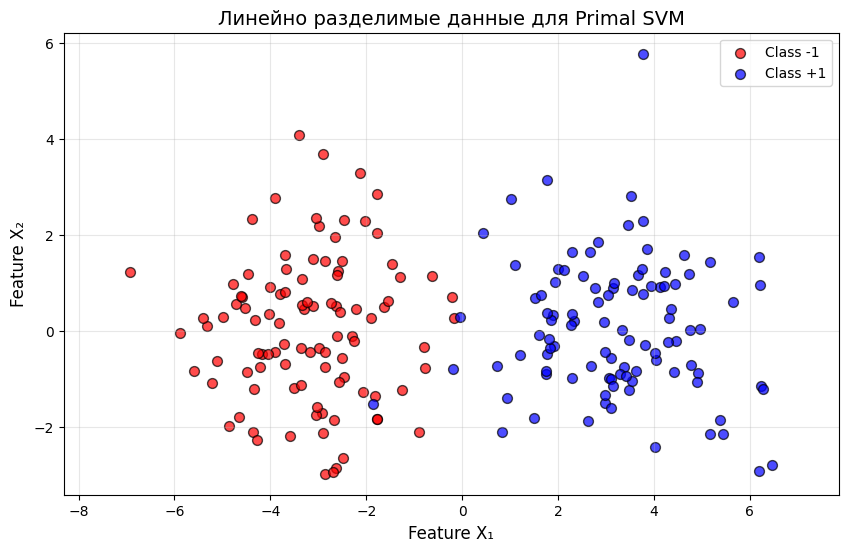

In [3]:
# ============================================
# Визуализация линейно разделимых данных
# ============================================

plt.figure(figsize=(10, 6))
plt.scatter(
    X_linear[y_linear == -1, 0],
    X_linear[y_linear == -1, 1],
    color='red',
    label='Class -1',
    s=50,
    alpha=0.7,
    edgecolors='k'
)
plt.scatter(
    X_linear[y_linear == 1, 0],
    X_linear[y_linear == 1, 1],
    color='blue',
    label='Class +1',
    s=50,
    alpha=0.7,
    edgecolors='k'
)

plt.xlabel('Feature X₁', fontsize=12)
plt.ylabel('Feature X₂', fontsize=12)
plt.title('Линейно разделимые данные для Primal SVM', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

## 📐 4. Разделяющая линия и Margin — геометрия SVM

### Уравнение гиперплоскости

В двумерном случае разделяющая линия (гиперплоскость) задаётся уравнением:

**w₁·x₁ + w₂·x₂ + b = 0**

где:
- **w = (w₁, w₂)** — вектор весов (нормаль к линии, перпендикулярен ей)
- **b** — смещение (bias)

### Почему w — это нормаль?

Возьмём две точки x₁ и x₂, лежащие на линии:
- w·x₁ + b = 0
- w·x₂ + b = 0

Вычтем: w·(x₁ − x₂) = 0

Вектор (x₁ − x₂) лежит **внутри** линии (соединяет две её точки). Его скалярное произведение с w равно нулю → значит **w перпендикулярен линии**.

### Расстояние от точки до линии

Для точки x₀ расстояние до линии вычисляется по формуле:

**d = |w·x₀ + b| / ||w||**

где ||w|| = √(w₁² + w₂²) — длина (норма) вектора w.

### Границы полосы (Margin)

SVM стремится максимизировать ширину "улицы" между классами. Границы этой улицы задаются двумя параллельными линиями:

- **w·x + b = +1** — ближайшие точки класса +1
- **w·x + b = -1** — ближайшие точки класса -1

### Ширина полосы (Margin)

Расстояние между этими двумя параллельными линиями:

**margin = 2 / ||w||**

**Доказательство (ключевой момент):**

Возьмём точки x⁺ на линии +1 и x⁻ на линии -1, и выберем их так, чтобы вектор (x⁺ − x⁻) был **параллелен нормали w** (кратчайший путь между линиями).

Запишем разность уравнений:
- (w·x⁺ + b) − (w·x⁻ + b) = 1 − (−1) = 2
- w·(x⁺ − x⁻) = 2

Так как x⁺ − x⁻ параллелен w, его можно записать как t · (w/||w||), где t — это искомая длина (расстояние между линиями).

Подставляем:
- w · (t · w/||w||) = 2
- t · ||w|| = 2
- **t = 2 / ||w||** ← это и есть margin!

### Что мы минимизируем?

Наша цель — **максимизировать margin = 2/||w||**.

Дробь тем больше, чем **меньше знаменатель ||w||**. Поэтому максимизация margin эквивалентна **минимизации ||w||²/2** (квадрат для гладкости, 1/2 для удобства дифференцирования).

### Оптимизационная задача (Primal)

**Минимизировать:** (1/2)·||w||²

**При условии:** yᵢ·(w·xᵢ + b) ≥ 1 для всех точек i

где yᵢ = +1 или -1 (метка класса).

Это и есть **примальная задача SVM** — мы будем решать её через градиентный спуск в Главе 2.

## 🎯 5. Визуализация разделяющей линии и Margin

### Теория

После обучения Primal SVM (Глава 2) мы получим w и b. Тогда мы сможем нарисовать:

1. **Разделяющую линию:** w·x + b = 0
2. **Верхнюю границу margin:** w·x + b = +1
3. **Нижнюю границу margin:** w·x + b = -1
4. **Опорные векторы** — точки, которые лежат ровно на границах margin

Здесь мы покажем **как это будет выглядеть**, используя предварительно обученную модель (в Главе 2 мы обучим её сами).

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


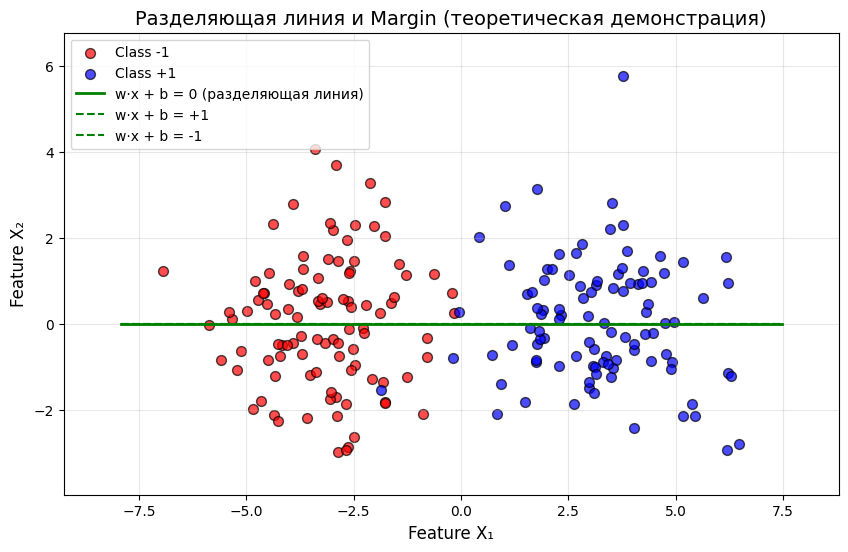

In [6]:
# ============================================
# Демонстрация разделяющей линии и margin
# ============================================

# Для демонстрации мы используем заранее известные w и b
# (в Главе 2 мы научимся их находить через градиентный спуск)

# Примерные значения w и b (полученные после обучения)
w_demo = np.array([0.8, 0.0])
b_demo = 0.0

# Создаём сетку для отрисовки линии
x_min, x_max = X_linear[:, 0].min() - 1, X_linear[:, 0].max() + 1
y_min, y_max = X_linear[:, 1].min() - 1, X_linear[:, 1].max() + 1

# Линия уровня для w·x + b = 0
xx = np.linspace(x_min, x_max, 100)
yy_sep = -(w_demo[0] * xx + b_demo) / w_demo[1] if w_demo[1] != 0 else np.zeros_like(xx)

# Линии уровня для w·x + b = ±1 (границы margin)
yy_plus = -(w_demo[0] * xx + b_demo - 1) / w_demo[1] if w_demo[1] != 0 else np.zeros_like(xx)
yy_minus = -(w_demo[0] * xx + b_demo + 1) / w_demo[1] if w_demo[1] != 0 else np.zeros_like(xx)

# Рисуем
plt.figure(figsize=(10, 6))

# Точки
plt.scatter(
    X_linear[y_linear == -1, 0],
    X_linear[y_linear == -1, 1],
    color='red', label='Class -1', s=50, alpha=0.7, edgecolors='k'
)
plt.scatter(
    X_linear[y_linear == 1, 0],
    X_linear[y_linear == 1, 1],
    color='blue', label='Class +1', s=50, alpha=0.7, edgecolors='k'
)

# Разделяющая линия
plt.plot(xx, yy_sep, 'g-', linewidth=2, label='w·x + b = 0 (разделяющая линия)')

# Границы margin
plt.plot(xx, yy_plus, 'g--', linewidth=1.5, label='w·x + b = +1')
plt.plot(xx, yy_minus, 'g--', linewidth=1.5, label='w·x + b = -1')

# Заливка полосы (margin)
plt.fill_between(xx, yy_minus, yy_plus, color='green', alpha=0.1)

plt.xlabel('Feature X₁', fontsize=12)
plt.ylabel('Feature X₂', fontsize=12)
plt.title('Разделяющая линия и Margin (теоретическая демонстрация)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

## 🧠 6. Генерация нелинейных данных для тестирования ядер

### Теория

Для тестирования ядер (RBF, Polynomial) нам нужны данные, которые **нельзя разделить прямой линией**. Мы сгенерируем три классических паттерна:

1. **Концентрические окружности (Circles)** — один класс внутри круга, другой — снаружи. Прямая линия не справится, нужна круговая граница (RBF-ядро).
2. **Два полумесяца (Moons)** — два изогнутых кластера. Классический тест для нелинейных классификаторов.
3. **XOR-паттерн** — четыре кластера по углам, классы расположены по диагонали.

Все эти паттерны встроены в sklearn и генерируются одной строкой.

In [7]:
# ============================================
# 2. Концентрические окружности (для RBF-ядра)
# ============================================

X_circles, y_circles = make_circles(
    n_samples=n_samples,
    factor=0.5,
    noise=0.05,
    random_state=42
)
y_circles = np.where(y_circles == 0, -1, 1)

# ============================================
# 3. Два полумесяца (Moons)
# ============================================

X_moons, y_moons = make_moons(
    n_samples=n_samples,
    noise=0.05,
    random_state=42
)
y_moons = np.where(y_moons == 0, -1, 1)

# ============================================
# 4. XOR-паттерн (вручную)
# ============================================

np.random.seed(42)
n_xor = n_samples // 4

# Четыре кластера по углам
X_xor_1 = np.random.randn(n_xor, 2) + np.array([-2, -2])
X_xor_2 = np.random.randn(n_xor, 2) + np.array([-2, 2])
X_xor_3 = np.random.randn(n_xor, 2) + np.array([2, -2])
X_xor_4 = np.random.randn(n_xor, 2) + np.array([2, 2])

X_xor = np.vstack([X_xor_1, X_xor_2, X_xor_3, X_xor_4])

# Метки по диагонали: класс -1 для левого-верхнего и правого-нижнего
y_xor = np.hstack([
    np.ones(n_xor),      # левый-нижний → +1
    -np.ones(n_xor),     # левый-верхний → -1
    -np.ones(n_xor),     # правый-нижний → -1
    np.ones(n_xor)       # правый-верхний → +1
])

print(f"X_circles shape: {X_circles.shape}")
print(f"X_moons shape: {X_moons.shape}")
print(f"X_xor shape: {X_xor.shape}")

X_circles shape: (200, 2)
X_moons shape: (200, 2)
X_xor shape: (200, 2)


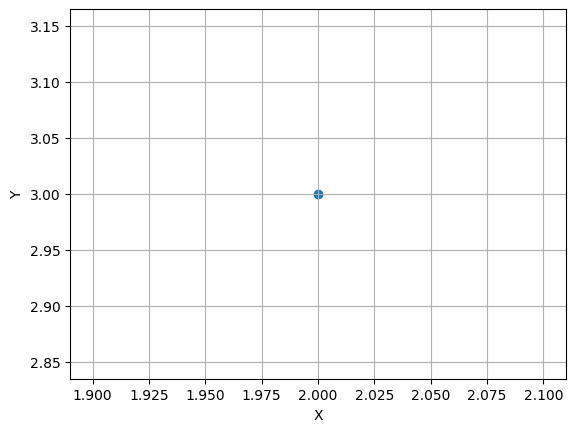

In [1]:
import numpy as np
import matplotlib.pyplot as plt

mean_minus1 = np.array([2.0, 3.0])

plt.scatter(mean_minus1[0], mean_minus1[1])
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()